# Reproducible result and its uncertainty

**The reproducible result**: the wave speed v at the protocol point

| parameter | value |
|---|---|
| A (coupling) | 1.0 |
| delta (asymmetry) | 0.001 |
| alpha (damping) | 0.10 |
| lattice N | 200 |
| timestep dt | 1e-4 |
| run time T | 400 |

Anyone with this repository reproduces it by running the cell below (about a
minute) or, for the full uncertainty analysis, `python3 scripts/uq_sweep.py`
(~40 minutes on 8 cores, or one SCRTP node via `scripts/uq_avon.sbatch`).
The ensemble results ship as CSVs in `results/` so this notebook runs from
cache in seconds.

**The uncertainty question**: the three physical parameters (delta, A, alpha)
carry manufacturing tolerances - we assume each is only known to +/-10%.
How uncertain does that make the wave speed, and which tolerance matters most?
Method: 256 simulations at Latin-hypercube samples of the tolerance box,
a Gaussian-process surrogate fitted to them (validated on 32 held-out runs),
and Sobol sensitivity indices computed from the surrogate.

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sys.path.insert(0, 'src')
from model import run_sim

FORCE_RERUN = False

def load_uq(path):
    if not os.path.exists(path):
        raise SystemExit(f"{path} missing - generate it with: python3 scripts/uq_sweep.py")
    return pd.read_csv(path, comment='#')

train = load_uq('results/uq_train.csv')
test  = load_uq('results/uq_test.csv')
print(f"loaded {len(train)} training runs, {len(test)} test runs")
print(f"all propagated: {train['v_sim'].notna().all() and test['v_sim'].notna().all()}")

loaded 256 training runs, 32 test runs
all propagated: True


In [2]:
# ── The single reproducible run (cached like every other expensive result) ────
CSV_PROTO = 'results/protocol_point.csv'
if FORCE_RERUN or not os.path.exists(CSV_PROTO):
    t0 = time.perf_counter()
    v_p, v_pred_p, ratio_p = run_sim(A=1.0, delta=0.001, alpha=0.10, N=200, T=400, dt=1e-4)
    pd.DataFrame([dict(v_sim=v_p, v_pred=v_pred_p, ratio=ratio_p,
                       wall_seconds=time.perf_counter()-t0)]).to_csv(CSV_PROTO, index=False)
row = pd.read_csv(CSV_PROTO).iloc[0]
v_protocol = row['v_sim']
print(f"protocol-point wave speed: v = {v_protocol:.4f} sites per unit time")
print(f"(energy-balance prediction {row['v_pred']:.4f}, ratio {row['ratio']:.3f} "
      f"- inside the validity region mapped in diaphragm_metafluid.ipynb)")

protocol-point wave speed: v = 0.2206 sites per unit time
(energy-balance prediction 0.2237, ratio 1.014 - inside the validity region mapped in diaphragm_metafluid.ipynb)


## Surrogate: learn v(delta, A, alpha) from the ensemble

A Gaussian process is fitted to the 256 training runs and judged on 32 runs it
never saw. If the surrogate predicts those held-out speeds accurately, it can
stand in for the simulator - each surrogate evaluation costs microseconds
instead of 50 seconds, which is what makes the sensitivity analysis below
affordable. This fitted model is also the project's scientific-ML component.

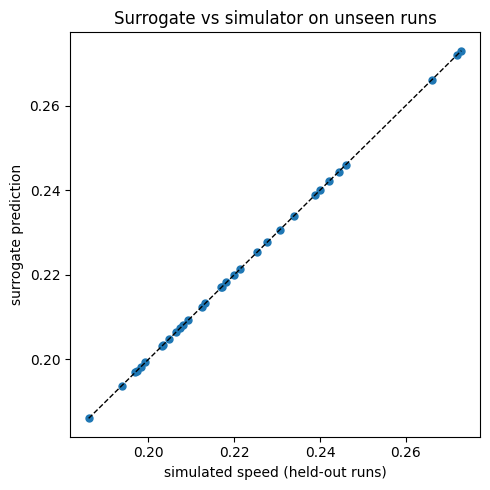

hold-out R^2  = 1.00000
hold-out RMSE = 1.64e-05  (0.01% of the mean speed)


In [3]:
import warnings
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

# Some optimizer restarts wander to a kernel bound and stop early; those fits
# are discarded in favour of the best restart. The kept fit is judged the honest
# way - on held-out runs it never saw (R^2 printed below) - so the optimizer
# chatter carries no information and is silenced.
warnings.filterwarnings('ignore', category=ConvergenceWarning)

PARAMS = ['delta', 'A', 'alpha']

def fit_gp(df):
    """Fit a GP to v_sim(delta, A, alpha); returns a predict(X) function."""
    X, y = df[PARAMS].values, df['v_sim'].values
    mu, sd = X.mean(axis=0), X.std(axis=0)          # standardise inputs
    kernel = (ConstantKernel(1.0) * Matern(length_scale=[1.0]*3, nu=2.5)
              + WhiteKernel(noise_level=1e-8, noise_level_bounds=(1e-12, 1e-4)))
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True,
                                  n_restarts_optimizer=5, random_state=0)
    gp.fit((X - mu) / sd, y)
    return lambda Xnew: gp.predict((np.asarray(Xnew) - mu) / sd)

predict = fit_gp(train)

# Hold-out validation: how well does the surrogate predict runs it never saw?
y_true = test['v_sim'].values
y_hat  = predict(test[PARAMS].values)
rmse   = np.sqrt(np.mean((y_hat - y_true)**2))
r2     = 1 - np.sum((y_hat - y_true)**2) / np.sum((y_true - y_true.mean())**2)

plt.figure(figsize=(5, 5))
plt.scatter(y_true, y_hat, s=25)
lims = [y_true.min(), y_true.max()]
plt.plot(lims, lims, 'k--', lw=1)
plt.xlabel('simulated speed (held-out runs)'); plt.ylabel('surrogate prediction')
plt.title('Surrogate vs simulator on unseen runs')
plt.tight_layout(); plt.show()

print(f"hold-out R^2  = {r2:.5f}")
print(f"hold-out RMSE = {rmse:.2e}  ({100*rmse/y_true.mean():.2f}% of the mean speed)")

## Which tolerance matters? Sobol sensitivity indices

Sobol indices split the variance of v between the three uncertain inputs.
First-order S1 = the share each parameter explains on its own; total ST adds
its share of interactions. Computed by Monte Carlo on the surrogate
(Saltelli sampling with Jansen's estimators, 4096 base samples - about
20,000 surrogate calls, which would have been 12 days of simulation).

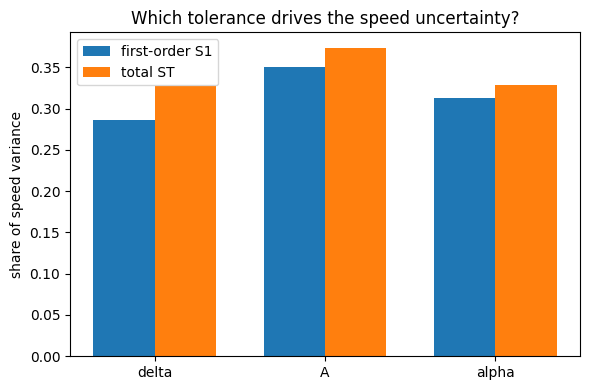

parameter  S1      ST
A         0.351   0.374
alpha     0.313   0.329
delta     0.286   0.327

sum of S1 = 0.950  (close to 1 -> interactions are weak)
ranking at the protocol point: A > alpha > delta


In [4]:
CENTRE, REL = np.array([0.001, 1.0, 0.10]), 0.10

def sobol_indices(predict, centre, rel=REL, n=4096, seed=0):
    """First-order and total Sobol indices on uniform +/-rel boxes (Jansen)."""
    rng = np.random.default_rng(seed)
    lo, hi = centre*(1-rel), centre*(1+rel)
    A_mat = lo + rng.random((n, 3))*(hi-lo)
    B_mat = lo + rng.random((n, 3))*(hi-lo)
    yA, yB = predict(A_mat), predict(B_mat)
    V = np.var(np.concatenate([yA, yB]))
    S1, ST = np.zeros(3), np.zeros(3)
    for i in range(3):
        ABi = A_mat.copy(); ABi[:, i] = B_mat[:, i]     # A with column i from B
        yABi = predict(ABi)
        S1[i] = 1 - 0.5*np.mean((yB - yABi)**2)/V       # shares only column i with B
        ST[i] = 0.5*np.mean((yA - yABi)**2)/V           # shares all but column i with A
    return S1, ST

S1, ST = sobol_indices(predict, CENTRE)

x = np.arange(3)
plt.figure(figsize=(6, 4))
plt.bar(x - 0.18, S1, width=0.36, label='first-order S1')
plt.bar(x + 0.18, ST, width=0.36, label='total ST')
plt.xticks(x, PARAMS); plt.ylabel('share of speed variance')
plt.title('Which tolerance drives the speed uncertainty?')
plt.legend(); plt.tight_layout(); plt.show()

order = np.argsort(S1)[::-1]
print("parameter  S1      ST")
for i in order:
    print(f"{PARAMS[i]:9} {S1[i]:.3f}   {ST[i]:.3f}")
print(f"\nsum of S1 = {S1.sum():.3f}  (close to 1 -> interactions are weak)")
print(f"ranking at the protocol point: {' > '.join(PARAMS[i] for i in order)}")

## The headline number

Two separate error bars, kept separate on purpose:

- **numerical**: how much the number moves with resolution. From the
  convergence studies in `diaphragm_metafluid.ipynb`, v is unchanged to
  4 decimal places for N >= 100, and the timestep study converges at
  second order with Cauchy differences ~1e-10 at dt = 1e-4. A conservative
  numerical tolerance is +/-0.0001.
- **parametric**: how much v varies across the +/-10% tolerance box,
  taken as the standard deviation of speed over the input distribution
  (surrogate propagation, cross-checked against the raw ensemble).

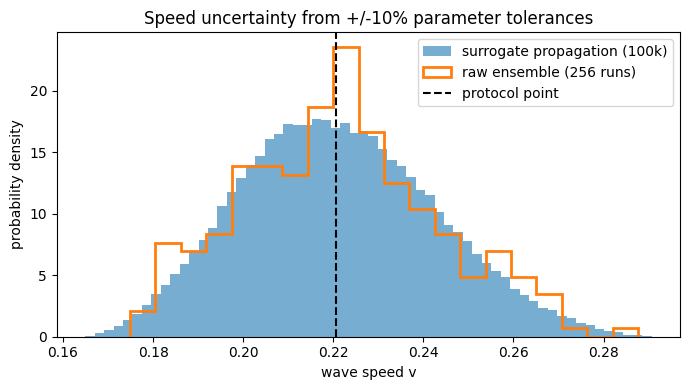

surrogate band : 0.0215   raw-ensemble band : 0.0219   (should agree)

REPRODUCIBLE RESULT:
  v = 0.2206  +/- 0.0001 (numerical)  +/- 0.0215 (parametric, +/-10% tolerances)
  i.e. the tolerance band is ~215x the numerical one - manufacturing precision, not the simulation, limits how well v can be known


In [5]:
# Parametric band: propagate 100,000 tolerance samples through the surrogate
rng = np.random.default_rng(1)
lo, hi = CENTRE*(1-REL), CENTRE*(1+REL)
X_mc  = lo + rng.random((100_000, 3))*(hi-lo)
v_mc  = predict(X_mc)
sigma_param = v_mc.std()
sigma_num   = 1e-4                       # conservative, from the convergence studies

plt.figure(figsize=(7, 4))
plt.hist(v_mc, bins=60, density=True, alpha=0.6, label='surrogate propagation (100k)')
plt.hist(train['v_sim'], bins=20, density=True, histtype='step', lw=2,
         label=f'raw ensemble ({len(train)} runs)')
plt.axvline(v_protocol, color='k', ls='--', label='protocol point')
plt.xlabel('wave speed v'); plt.ylabel('probability density')
plt.title('Speed uncertainty from +/-10% parameter tolerances')
plt.legend(); plt.tight_layout(); plt.show()

print(f"surrogate band : {sigma_param:.4f}   raw-ensemble band : {train['v_sim'].std():.4f}   (should agree)")
print()
print(f"REPRODUCIBLE RESULT:")
print(f"  v = {v_protocol:.4f}  +/- {sigma_num:.4f} (numerical)  +/- {sigma_param:.4f} (parametric, +/-10% tolerances)")
print(f"  i.e. the tolerance band is ~{sigma_param/sigma_num:.0f}x the numerical one - "
      f"manufacturing precision, not the simulation, limits how well v can be known")

## Does the sensitivity ranking hold everywhere? A check near the validity edge

The ranking above is a statement about the protocol point. Near the edge of
the energy-balance validity region (alpha = 0.02, underdamped, where ringing
appears) the physics changes, so the sensitivities might too. Same pipeline,
second ensemble centred there.

edge surrogate hold-out R^2 = 1.00000  (64 training runs)


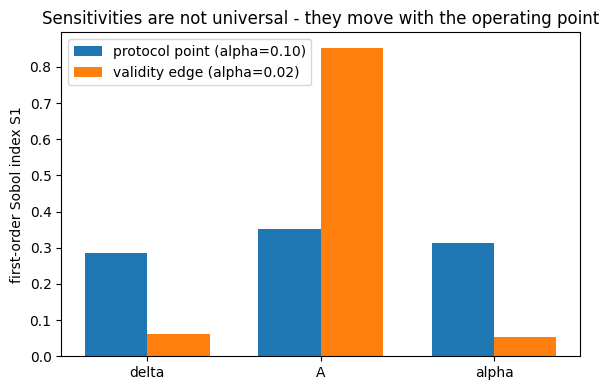

           protocol   edge
delta      0.286      0.062
A          0.351      0.853
alpha      0.313      0.053

ranking at the edge: A > delta > alpha
Takeaway: quote sensitivities together with the operating point they were computed at.


In [6]:
edge_train = load_uq('results/uq_edge_train.csv')
edge_test  = load_uq('results/uq_edge_test.csv')

predict_e  = fit_gp(edge_train)
y_te, y_he = edge_test['v_sim'].values, predict_e(edge_test[PARAMS].values)
r2_e = 1 - np.sum((y_he-y_te)**2)/np.sum((y_te-y_te.mean())**2)
print(f"edge surrogate hold-out R^2 = {r2_e:.5f}  ({len(edge_train)} training runs)")

CENTRE_E = np.array([0.001, 1.0, 0.02])
S1e, STe = sobol_indices(predict_e, CENTRE_E)

x = np.arange(3)
plt.figure(figsize=(6, 4))
plt.bar(x - 0.18, S1,  width=0.36, label='protocol point (alpha=0.10)')
plt.bar(x + 0.18, S1e, width=0.36, label='validity edge (alpha=0.02)')
plt.xticks(x, PARAMS); plt.ylabel('first-order Sobol index S1')
plt.title('Sensitivities are not universal - they move with the operating point')
plt.legend(); plt.tight_layout(); plt.show()

oe = np.argsort(S1e)[::-1]
print("           protocol   edge")
for i in range(3):
    print(f"{PARAMS[i]:9}  {S1[i]:.3f}      {S1e[i]:.3f}")
print(f"\nranking at the edge: {' > '.join(PARAMS[i] for i in oe)}")
print("Takeaway: quote sensitivities together with the operating point they were computed at.")

## A different question: diaphragms that differ from each other

Everything above varies one $\delta$ for the whole chain, which asks *if this batch came out
off-spec, how wrong is the speed?* That is the right question for a systematic manufacturing
offset, and it is the number quoted in the abstract.

It is not the only question. Real diaphragms differ from **each other**, so a more realistic
chain has

$$\delta_n = \delta_0\,(1 + \sigma\,\varepsilon_n), \qquad \varepsilon_n \sim N(0,1),$$

a different asymmetry at every site. These two uncertainties are easy to conflate and should
not be: the first shifts the whole chain, the second scrambles it internally.

There is a reason to expect the second to be much the smaller. A front does not respond to
the diaphragm it happens to be sitting on; it is an extended object driven by the many sites
it spans and crosses while the speed is being measured. Averaging over many independent
draws of $\delta$ should suppress their scatter in the usual $1/\sqrt{n}$ way. The ensemble
below measures whether it does, and by how much.

In [ ]:
# ── Per-diaphragm disorder: does it self-average? ────────────────────────────
# Generated by scripts/disorder_sweep.py (25 runs, ~4 min on 9 workers).
# sigma is the relative site-to-site scatter in delta; sigma=0 is the exact
# homogeneous control and must reproduce the protocol-point speed.

df_dis = pd.read_csv('results/disorder.csv', comment='#')

v_hom = df_dis[df_dis.sigma == 0].v_sim.iloc[0]
rows_d = []
for s in sorted(df_dis.sigma.unique()):
    vs = df_dis[df_dis.sigma == s].v_sim.values
    rows_d.append(dict(sigma=s, n=len(vs), mean=vs.mean(),
                       spread=100*vs.std(ddof=1)/vs.mean() if len(vs) > 1 else 0.0,
                       shift=100*(vs.mean() - v_hom)/v_hom))
dis = pd.DataFrame(rows_d)
nz  = dis[dis.sigma > 0]
suppression = (nz.spread/(100*nz.sigma)).mean()      # spread as a fraction of the disorder

PARAMETRIC = 9.7        # % — the single-delta band from the section above

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(100*nz.sigma, nz.spread, 'o-', color='crimson', label='per-diaphragm disorder')
ax1.plot([0, 100*nz.sigma.max()], [0, suppression*100*nz.sigma.max()], 'k--', lw=1,
         label=rf'linear, slope {suppression:.3f}')
ax1.axhline(PARAMETRIC, color='steelblue', ls=':', lw=1.8,
            label=f'parametric band ({PARAMETRIC}%)')
ax1.set_xlabel(r'per-site disorder  $\sigma$  (%)')
ax1.set_ylabel('spread in wave speed (%)')
ax1.set_title('Disorder barely moves the speed'); ax1.legend(fontsize=8)

for s in sorted(df_dis.sigma.unique()):
    vs = df_dis[df_dis.sigma == s].v_sim.values
    ax2.plot(np.full(len(vs), 100*s), vs, 'o', ms=6, alpha=0.75,
             color='crimson' if s > 0 else 'k')
ax2.axhline(v_hom, color='k', lw=0.8, ls='--', label='homogeneous chain')
ax2.set_xlabel(r'per-site disorder  $\sigma$  (%)'); ax2.set_ylabel('$v$')
ax2.set_title('Every realisation, not just the spread'); ax2.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures/disorder.png', dpi=120, bbox_inches='tight')
plt.show()

_s10 = dis[np.isclose(dis.sigma, 0.10)].iloc[0]
tbl = "\n".join(f"| {100*r.sigma:.0f}% | {r.spread:.2f}% | {r.shift:+.2f}% |"
                for r in nz.itertuples())
display(Markdown(f"""
**Per-diaphragm disorder self-averages, and by roughly an order of magnitude.**

| per-site scatter $\\sigma$ | spread in $v$ | mean shift in $v$ |
|:--:|:--:|:--:|
{tbl}

The spread is **linear in $\\sigma$** with slope {suppression:.3f}, constant to the third
decimal place across the whole range: scattering $\\delta$ by $\\sigma$ scatters the wave
speed by only $\\approx \\sigma/{1/suppression:.0f}$.

The comparison that matters for the reported uncertainty: at $\\sigma = 10\\%$, the same
tolerance used for the parametric study, per-diaphragm disorder contributes
**{_s10['spread']:.2f}%** against the parametric band's **{PARAMETRIC}%** — about
{PARAMETRIC/_s10['spread']:.0f} times less. A chain whose diaphragms differ from one another
is far better behaved than a chain whose diaphragms are uniformly off-spec, so the abstract
number is rightly the parametric one.

Two caveats worth stating rather than hiding. The suppression is stronger than the front
width alone would explain: the speed is fitted over a window during which the front crosses
of order seventy sites, so it averages over those rather than over the handful the front
spans at any instant, and $1/\\sqrt{{70}} \\approx 0.12$ is the right order for the
{suppression:.3f} measured. And disorder does not merely blur the speed, it raises it
slightly — {_s10['shift']:+.2f}% at $\\sigma = 10\\%$, growing with $\\sigma$ — which is small
but systematic across every seed, and not something this ensemble was designed to explain.
"""))

## What this delivers for the report

- **Section 3.4 (compulsory)**: the reproducible result
  v = value +/- numerical +/- parametric, with the protocol, seeds and
  versions logged in the CSVs, and the runs reproducible by
  `scripts/uq_sweep.py` locally or `scripts/uq_avon.sbatch` on SCRTP.
- **Sensitivity decomposition**: Sobol indices say which manufacturing
  tolerance to spend money tightening, and the edge-point check shows the
  answer depends on the operating point.
- **Scientific-ML training goal**: the validated Gaussian-process surrogate
  (hold-out R^2 reported above) is the learned model that made the
  20,000-evaluation sensitivity analysis affordable.